# A/B Testing Analysis with Snowflake and Python

## Objective
This project evaluates whether a new landing page (treatment) improved user conversion compared to the existing landing page (control).

## Tools Used
- Snowflake
- SQL
- Python
- pandas
- SciPy
- Matplotlib

## Workflow
1. Raw data loaded into Snowflake
2. Data cleaned and validated in SQL
3. Mismatches and duplicates removed
4. Final cleaned dataset exported for analysis
5. Statistical testing performed in Python
6. Business recommendation provided

Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest

## Load Cleaned Dataset

The final cleaned dataset was exported from Snowflake after:
- standardising data types
- removing mismatches between assigned groups and landing pages
- removing duplicate users

In [6]:
df = pd.read_csv("../data/ab_final.csv")
countries = pd.read_csv("../data/countries.csv")

df.head()


,USER_ID,EVENT_TIME,GROUP_TYPE,LANDING_PAGE,CONVERTED
0,731207,2017-01-16 02:52:31.979,treatment,new_page,0
1,643834,2017-01-23 19:47:09.078,control,old_page,0
2,859104,2017-01-23 22:08:39.261,control,old_page,1
3,758700,2017-01-03 22:00:00.881,treatment,new_page,0
4,895292,2017-01-21 02:42:07.494,control,old_page,1


Check structure of the dataset

In [7]:
df.shape

(290584, 5)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290584 entries, 0 to 290583
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   user_id       290584 non-null  int64
 1   event_time    290584 non-null  str  
 2   group_type    290584 non-null  str  
 3   landing_page  290584 non-null  str  
 4   converted     290584 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.1 MB


In [13]:
df.isna().sum()

user_id         0
event_time      0
group_type      0
landing_page    0
converted       0
dtype: int64

In [9]:
df.columns

Index(['USER_ID', 'EVENT_TIME', 'GROUP_TYPE', 'LANDING_PAGE', 'CONVERTED'], dtype='str')

In [10]:
df.columns = [c.lower() for c in df.columns]

The dataset contains the final validated observations used for the A/B test. Column names were converted to lowercase for consistency.

## Sanity Checks

Before statistical analysis, the cleaned dataset is checked to confirm:
- only valid treatment-control assignments remain
- no duplicate users remain

In [14]:
df["group_type"].value_counts()

group_type
treatment    145310
control      145274
Name: count, dtype: int64

In [15]:
df["landing_page"].value_counts()

landing_page
new_page    145310
old_page    145274
Name: count, dtype: int64

In [16]:
df.duplicated(subset="user_id").sum()

np.int64(0)

The sanity checks confirm that the final dataset contains no duplicate users and no mismatched treatment-page assignments.

## Conversion Rate by Group

The first step is to compare conversion performance between the control and treatment groups.

In [17]:
summary = (
    df.groupby("group_type")["converted"]
      .agg(users="count", conversions="sum", conversion_rate="mean")
      .reset_index()
)

summary

,group_type,users,conversions,conversion_rate
0,control,145274,17489,0.120386
1,treatment,145310,17264,0.118808


The summary table shows that the treatment group recorded a slightly lower conversion rate than the control group.

## Visual Comparison of Conversion Rates

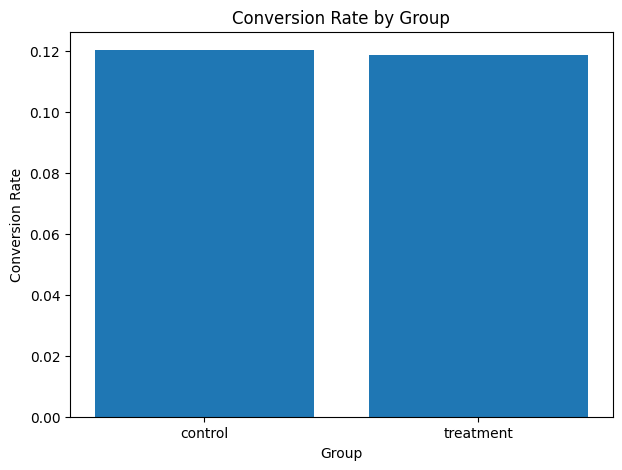

In [18]:
plt.figure(figsize=(7,5))
plt.bar(summary["group_type"], summary["conversion_rate"])
plt.title("Conversion Rate by Group")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")
plt.show()

The chart suggests that the treatment group underperformed slightly relative to the control group. However, statistical testing is required to determine whether this difference is meaningful.


## Hypothesis

## Hypothesis Test

To determine whether the observed difference in conversion rates is statistically significant, a two-sample t-test is performed.

### Hypotheses
- **Null hypothesis (H0):** There is no difference in conversion rates between the control and treatment groups.
- **Alternative hypothesis (H1):** There is a difference in conversion rates between the two groups.


In [21]:
control = df[df["group_type"] == "control"]["converted"]
treatment = df[df["group_type"] == "treatment"]["converted"]

t_stat, p_value = ttest_ind(treatment, control, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -1.310922637465592
P-value: 0.1898849379157832


## Results Interpretation

The t-test returned:
- **T-statistic:** -1.3109
- **P-value:** 0.1899

Using a significance level of 0.05, the p-value is greater than the threshold. Therefore, we fail to reject the null hypothesis.

This means the observed difference in conversion rates is not statistically significant.

## Conclusion

The treatment group achieved a slightly lower conversion rate (11.88%) than the control group (12.04%). However, the difference was not statistically significant (p = 0.1899).

Based on this analysis, there is insufficient evidence to conclude that the new landing page improves user conversion. The business should retain the existing landing page unless further experimentation suggests otherwise.